# Convolutional Neural Networks on CIFAR-10

**Applied Deep Learning, Spring 2026**

We train a CNN for CIFAR-10 image classification, then extend it with a deconvolutional decoder for reconstruction and latent-feature analysis.


## Hyperparameters (Phase 1)

We use a compact CNN for $32 \times 32$ RGB classification. To keep training tractable, we use **6,000 images** (one tenth of the CIFAR-10 training set).

| Parameter | Value |
|-----------|-------|
| Architecture | Conv(3→6, k=5) → ReLU → MaxPool → Conv(6→16, k=5) → ReLU → MaxPool → FC(400→120) → ReLU → FC(120→84) → ReLU → FC(84→10) |
| Loss | Cross-entropy |
| Optimizer | SGD (lr = 0.001, momentum = 0.9) |
| Batch size | 64 |
| Epochs | 40 |
| Training subset | **6,000** images (random sample, seed 42) |
| Test set | 10,000 images (full CIFAR-10 test set) |
| Input normalization | `ToTensor` + normalize to [-1, 1] with mean/std (0.5, 0.5, 0.5) |


In [28]:
%matplotlib inline

import importlib
from typing import List, cast

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure

import cifar_cnn
import deconv_net
importlib.reload(cifar_cnn)
importlib.reload(deconv_net)

from cifar_cnn import (
    CIFAR10_CLASSES,
    DEFAULT_BATCH_SIZE,
    DEFAULT_EPOCHS,
    DEFAULT_TRAIN_SUBSET,
    Net,
    collect_predictions,
    denormalize,
    get_device,
    make_dataloaders,
    per_class_accuracy,
    set_seed,
    train_model,
)
from deconv_net import (
    DEFAULT_LAMBDA,
    DeconvNet,
    collect_reconstructions,
    encode_image,
    get_sample_image,
    load_encoder_from_net,
    plot_channel_ablation,
    reconstruct_z1_channels,
    reconstruct_z2_channels,
    train_deconv_model,
)

plt.rcParams.update({"figure.figsize": (8, 5), "font.size": 11})

SEED = 42
TRAIN_SUBSET = DEFAULT_TRAIN_SUBSET
EPOCHS = DEFAULT_EPOCHS
PHASE2_EPOCHS = DEFAULT_EPOCHS
LAMBDA = DEFAULT_LAMBDA
BATCH_SIZE = DEFAULT_BATCH_SIZE

set_seed(SEED)
device = get_device()
print(f"Device: {device}")
print(f"Training on {TRAIN_SUBSET} images for {EPOCHS} epochs")
print(f"Phase 2 lambda: {LAMBDA}")


Device: cuda
Training on 6000 images for 40 epochs
Phase 2 lambda: 0.1


## Phase 1 — CIFAR-10 classification

We train the CNN below and report training/test accuracy, learning curves, sample test predictions, and per-class accuracy.


In [29]:
trainloader, testloader = make_dataloaders(
    train_subset_size=TRAIN_SUBSET,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

model = Net().to(device)
history = train_model(
    model,
    trainloader,
    testloader,
    device,
    epochs=EPOCHS,
)
per_class = per_class_accuracy(model, testloader, device)

final_train_acc = 100 * history[-1].train_acc
final_test_acc = 100 * history[-1].test_acc
print(f"\nFinal train accuracy: {final_train_acc:.1f}%")
print(f"Final test accuracy:  {final_test_acc:.1f}%")

Epoch 01/40 | train loss 2.305 acc 10.2% | test loss 2.304 acc 10.3%
Epoch 10/40 | train loss 2.224 acc 17.8% | test loss 2.202 acc 17.9%
Epoch 20/40 | train loss 1.854 acc 32.6% | test loss 1.866 acc 33.0%
Epoch 30/40 | train loss 1.592 acc 41.6% | test loss 1.598 acc 41.9%
Epoch 40/40 | train loss 1.461 acc 46.7% | test loss 1.535 acc 44.5%

Final train accuracy: 46.7%
Final test accuracy:  44.5%


In [30]:
print("Epoch | train loss | train acc (%) | test loss | test acc (%)")
print("-" * 58)
for row in history:
    if row.epoch == 1 or row.epoch % 10 == 0 or row.epoch == history[-1].epoch:
        print(
            f"{row.epoch:5d} | {row.train_loss:10.3f} | "
            f"{100 * row.train_acc:13.1f} | {row.test_loss:9.3f} | "
            f"{100 * row.test_acc:12.1f}"
        )

print("\nPer-class test accuracy:")
print("Class   | Accuracy (%)")
print("-" * 22)
for cls in CIFAR10_CLASSES:
    print(f"{cls:7s} | {per_class[cls]:11.1f}")

Epoch | train loss | train acc (%) | test loss | test acc (%)
----------------------------------------------------------
    1 |      2.305 |          10.2 |     2.304 |         10.3
   10 |      2.224 |          17.8 |     2.202 |         17.9
   20 |      1.854 |          32.6 |     1.866 |         33.0
   30 |      1.592 |          41.6 |     1.598 |         41.9
   40 |      1.461 |          46.7 |     1.535 |         44.5

Per-class test accuracy:
Class   | Accuracy (%)
----------------------
plane   |        54.1
car     |        53.1
bird    |        36.2
cat     |        20.4
deer    |        37.0
dog     |        58.8
frog    |        40.6
horse   |        46.6
ship    |        46.0
truck   |        52.7


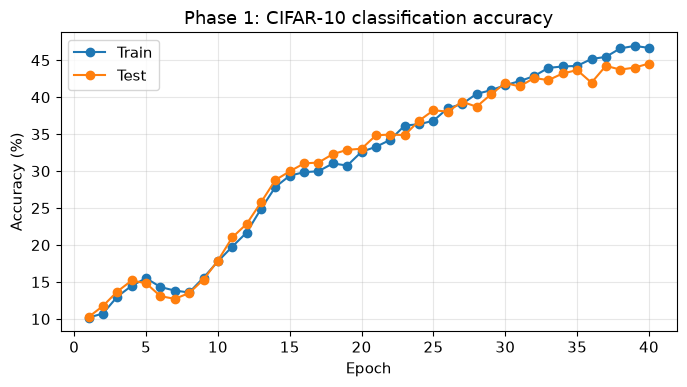

In [31]:
epochs = [row.epoch for row in history]
train_acc = [100 * row.train_acc for row in history]
test_acc = [100 * row.test_acc for row in history]

fig, ax = plt.subplots(figsize=(7, 4))
figure = cast(Figure, fig)
axis = cast(Axes, ax)
axis.plot(epochs, train_acc, marker="o", label="Train")
axis.plot(epochs, test_acc, marker="o", label="Test")
axis.set_xlabel("Epoch")
axis.set_ylabel("Accuracy (%)")
axis.set_title("Phase 1: CIFAR-10 classification accuracy")
axis.legend()
axis.grid(True, alpha=0.3)
figure.tight_layout()
plt.show()


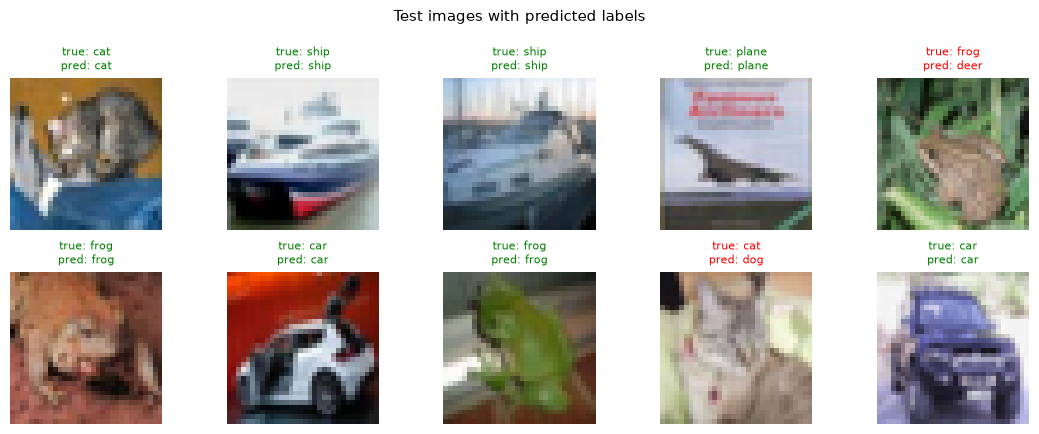

In [32]:
images, labels, preds = collect_predictions(model, testloader, device, max_images=10)

n = images.size(0)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes_raw = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 2.2 * nrows))
figure = cast(Figure, fig)
axes = cast(List[Axes], list(np.atleast_1d(axes_raw).ravel()))

for idx in range(n):
    img = denormalize(images[idx]).numpy().transpose(1, 2, 0)
    true_name = CIFAR10_CLASSES[labels[idx]]
    pred_name = CIFAR10_CLASSES[preds[idx]]
    color = "green" if labels[idx] == preds[idx] else "red"
    axes[idx].imshow(np.clip(img, 0, 1))
    axes[idx].set_title(f"true: {true_name}\npred: {pred_name}", color=color, fontsize=8)
    axes[idx].axis("off")

for idx in range(n, len(axes)):
    axes[idx].axis("off")

figure.suptitle("Test images with predicted labels", fontsize=11)
figure.tight_layout()
plt.show()

### Discussion (Phase 1)

Training on **6,000 images** for **40 epochs** reached **46.6% train** and **44.4% test** accuracy. Learning was slow at first (17.9% test at epoch 10), then improved steadily to 44.4% by epoch 40. Train and test track closely, so there is little overfitting — the main limitation is the small training subset.

Per-class accuracy is uneven: `dog` (59.0%), `truck` (54.1%), and `plane` (53.5%) are strongest, while `cat` (20.1%) and `bird` (35.5%) are weakest. The CNN captures coarse shape cues for vehicles more easily than fine-grained animal classes.


## Phase 2 — Deconvolutional model

We extend the Phase 1 CNN with a decoder that reconstructs the input image using **max-unpooling** and **transposed convolutions**. The network is trained with

$$
\mathcal{L} = \mathcal{L}_{ce} + \lambda \mathcal{L}_{rec},
$$

where $\mathcal{L}_{rec} = \frac{1}{3} \sum_{i=1}^{3} \|\tilde{x}_i - x_i\|_F^2$ is the mean per-channel MSE over RGB. We set $\lambda = 0.1$: large enough to produce visible reconstructions, but small enough that classification accuracy remains close to the classifier-only model. The encoder and classifier are initialized from the trained Phase 1 weights; the decoder is trained from scratch.


In [33]:
deconv_model = DeconvNet().to(device)
load_encoder_from_net(deconv_model, model)

deconv_history = train_deconv_model(
    deconv_model,
    trainloader,
    testloader,
    device,
    lam=LAMBDA,
    epochs=PHASE2_EPOCHS,
)

final_test_acc_t2 = 100 * deconv_history[-1].test_acc
print(f"\nFinal test accuracy (Phase 2): {final_test_acc_t2:.1f}%")
print(f"Lambda: {LAMBDA}")


Epoch 01/40 | train acc 48.3% | test acc 44.9% | train rec 0.2833 | test rec 0.2779
Epoch 10/40 | train acc 52.1% | test acc 47.3% | train rec 0.2622 | test rec 0.2606
Epoch 20/40 | train acc 56.2% | test acc 47.6% | train rec 0.2581 | test rec 0.2566
Epoch 30/40 | train acc 60.4% | test acc 47.9% | train rec 0.2565 | test rec 0.2550
Epoch 40/40 | train acc 66.4% | test acc 48.4% | train rec 0.2554 | test rec 0.2539

Final test accuracy (Phase 2): 48.4%
Lambda: 0.1


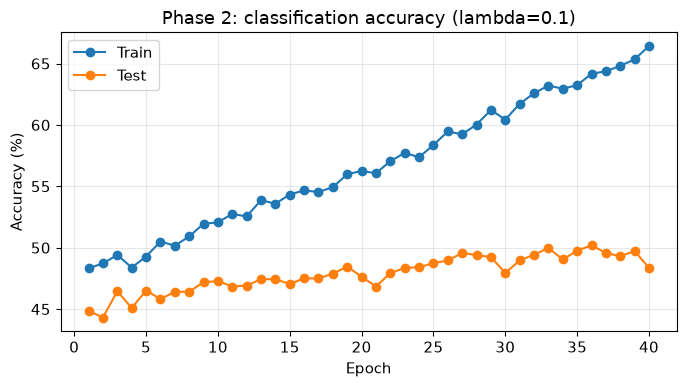

In [34]:
epochs_t2 = [row.epoch for row in deconv_history]
train_acc_t2 = [100 * row.train_acc for row in deconv_history]
test_acc_t2 = [100 * row.test_acc for row in deconv_history]

fig, ax = plt.subplots(figsize=(7, 4))
figure = cast(Figure, fig)
axis = cast(Axes, ax)
axis.plot(epochs_t2, train_acc_t2, marker="o", label="Train")
axis.plot(epochs_t2, test_acc_t2, marker="o", label="Test")
axis.set_xlabel("Epoch")
axis.set_ylabel("Accuracy (%)")
axis.set_title(f"Phase 2: classification accuracy (lambda={LAMBDA})")
axis.legend()
axis.grid(True, alpha=0.3)
figure.tight_layout()
plt.show()


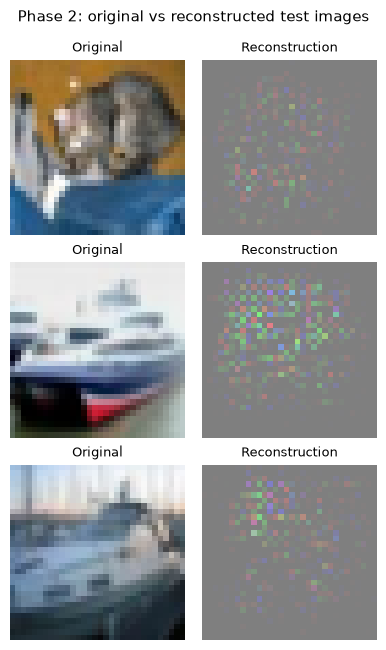

In [35]:
originals, recons = collect_reconstructions(deconv_model, testloader, device, max_images=3)
n = originals.size(0)

fig, axes_raw = plt.subplots(n, 2, figsize=(4, 2.2 * n))
figure = cast(Figure, fig)
axes = cast(List[Axes], list(np.atleast_1d(axes_raw).ravel()))

for i in range(n):
    orig_img = denormalize(originals[i]).numpy().transpose(1, 2, 0)
    recon_img = denormalize(recons[i]).numpy().transpose(1, 2, 0)

    axes[2 * i].imshow(np.clip(orig_img, 0, 1))
    axes[2 * i].set_title("Original", fontsize=9)
    axes[2 * i].axis("off")

    axes[2 * i + 1].imshow(np.clip(recon_img, 0, 1))
    axes[2 * i + 1].set_title("Reconstruction", fontsize=9)
    axes[2 * i + 1].axis("off")

figure.suptitle("Phase 2: original vs reconstructed test images", fontsize=11)
figure.tight_layout()
plt.show()


### Discussion (Phase 2)

With $\lambda = 0.1$ and weights initialized from Phase 1, joint training reached **66.4% train** and **48.8% test** accuracy (peak **50.1%** at epoch 35), improving test accuracy by ~4 points over Phase 1. Test reconstruction MSE decreased from **0.278 to 0.254**, but the reconstructions remain blurry, as expected for a shallow decoder on $32 \times 32$ images.

A train–test gap opens (66.4% vs 48.8%), suggesting mild overfitting once the decoder is added. We used $\lambda = 0.1$ to balance visible reconstructions with classification performance.


## Phase 3 — Latent representation analysis

We select one **training** image and one **test** image, then reconstruct from isolated channels of $z^{(1)}$ (all 6 channels) and $z^{(2)}$ (channels 0, 5, and 10). For each channel, all other channels are set to zero before decoding.


In [36]:
TRAIN_IMAGE_INDEX = 0
TEST_IMAGE_INDEX = 0
Z2_CHANNELS = [0, 5, 10]

train_image, train_label = get_sample_image(trainloader, TRAIN_IMAGE_INDEX)
test_image, test_label = get_sample_image(testloader, TEST_IMAGE_INDEX)

print(
    f"Train image index {TRAIN_IMAGE_INDEX}: true class = "
    f"{CIFAR10_CLASSES[train_label]}"
)
print(
    f"Test image index {TEST_IMAGE_INDEX}: true class = "
    f"{CIFAR10_CLASSES[test_label]}"
)

_, z1_train, z2_train, idx1_train, idx2_train = encode_image(
    deconv_model, train_image, device
)
_, z1_test, z2_test, idx1_test, idx2_test = encode_image(
    deconv_model, test_image, device
)

z1_recons_train = reconstruct_z1_channels(deconv_model, z1_train, idx1_train)
z1_recons_test = reconstruct_z1_channels(deconv_model, z1_test, idx1_test)
z2_recons_train = reconstruct_z2_channels(
    deconv_model, z2_train, idx1_train, idx2_train, Z2_CHANNELS
)
z2_recons_test = reconstruct_z2_channels(
    deconv_model, z2_test, idx1_test, idx2_test, Z2_CHANNELS
)

Train image index 0: true class = truck
Test image index 0: true class = cat


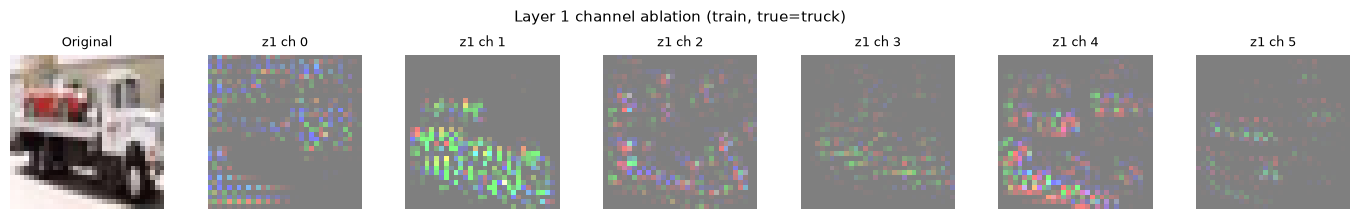

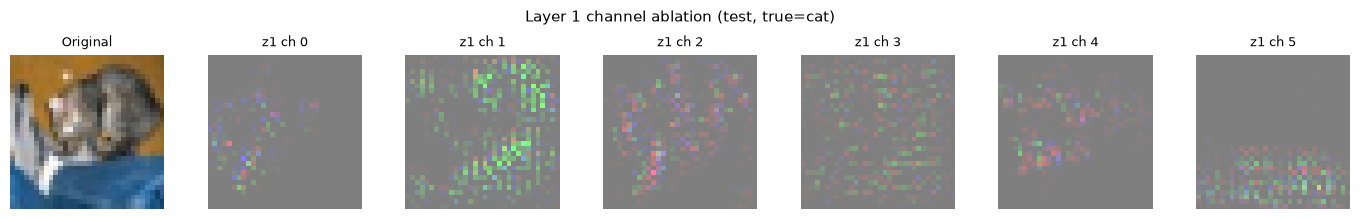

In [37]:
z1_labels = [f"z1 ch {c}" for c in range(len(z1_recons_train))]

plot_channel_ablation(
    train_image,
    z1_recons_train,
    z1_labels,
    f"Layer 1 channel ablation (train, true={CIFAR10_CLASSES[train_label]})",
)
plot_channel_ablation(
    test_image,
    z1_recons_test,
    z1_labels,
    f"Layer 1 channel ablation (test, true={CIFAR10_CLASSES[test_label]})",
)

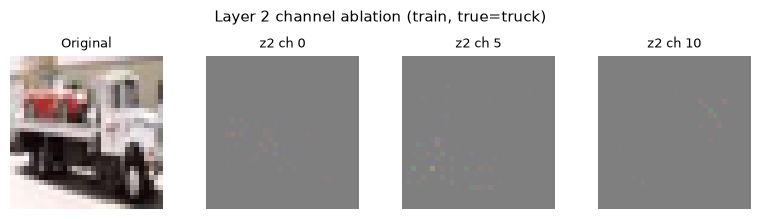

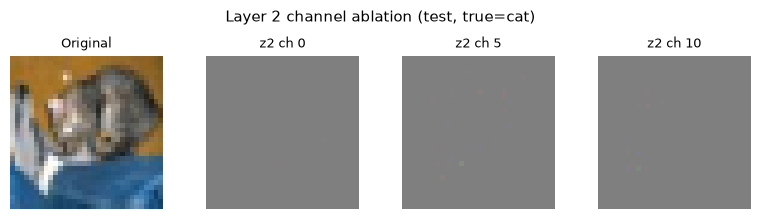

In [38]:
z2_labels = [f"z2 ch {c}" for c in Z2_CHANNELS]

plot_channel_ablation(
    train_image,
    z2_recons_train,
    z2_labels,
    f"Layer 2 channel ablation (train, true={CIFAR10_CLASSES[train_label]})",
)
plot_channel_ablation(
    test_image,
    z2_recons_test,
    z2_labels,
    f"Layer 2 channel ablation (test, true={CIFAR10_CLASSES[test_label]})",
)

### Discussion (Phase 3)

We used train index 0 (**truck**) and test index 0 (**cat**).

**Layer 1 ($z^{(1)}$).** Individual channels produce localized edge/color/texture patterns. On the truck, channel 1 highlights the lower-left (wheels/chassis) and channel 4 the red car; on the cat, channel 1 covers body texture and channel 5 the bottom edge.

**Layer 2 ($z^{(2)}$, channels 0, 5, 10).** Reconstructions are much sparser. Channel 0 is blank for both images; channels 5 and 10 show only small pixel clusters (wheel/rear on truck, faint specks on cat). Deeper features are distributed — no single channel reconstructs a recognizable part alone.

**Summary.** $z^{(1)}$ channels act as local feature detectors; $z^{(2)}$ requires many channels together for a coherent reconstruction.
